In [1]:
from qihc.stochastic import load_lookup_table
import numpy as np
import pandas as pd
from qihc.stochastic import DATA_DIR
import matplotlib.pyplot as plt

In [4]:
scale_input = 0.1
scale_mux = 0.5
bit_length = 128
print("--------------------------------------------------")
for i in range(10):
    p1, p2 = np.random.rand(2)
    simulated_sum = load_lookup_table(
        mode='MUX',
        p1=p1,
        p2=p2,
        scale_input=scale_input,
        scale_mux=scale_mux,
        bit_length=bit_length
    )
    print(f"p1={np.round(p1, 6)}, p2={np.round(p2, 6)}: {simulated_sum}, real value: [{np.round((p1 * scale_mux + p2 * (1 - scale_mux)), 6)}]")
print("--------------------------------------------------")

--------------------------------------------------
Loading lookup table for mode: MUX...
p1=0.718145, p2=0.488044: [0.890625], real value: [0.603094]
p1=0.558527, p2=0.573004: [0.4921875], real value: [0.565766]
p1=0.83483, p2=0.065922: [0.4453125], real value: [0.450376]
p1=0.00109, p2=0.852654: [0.3125], real value: [0.426872]
p1=0.307158, p2=0.552979: [0.2890625], real value: [0.430068]
p1=0.430537, p2=0.257112: [0.3046875], real value: [0.343825]
p1=0.393747, p2=0.82093: [0.6015625], real value: [0.607338]
p1=0.421387, p2=0.628302: [0.703125], real value: [0.524844]
p1=0.918433, p2=0.789037: 1, real value: [0.853735]
p1=0.959605, p2=0.039361: [0.234375], real value: [0.499483]
--------------------------------------------------


In [5]:
# test for AND
for i in range(10):
    p1, p2 = np.random.rand(2)
    scale_input = 1
    bit_length = 128
    simulated_sum = load_lookup_table(
        mode='AND',
        p1=p1,
        p2=p2,
        scale_input=scale_input,
        bit_length=bit_length
    )
    print(f"p1={np.round(p1, 6)}, p2={np.round(p2, 6)}: {simulated_sum}, real value: [{np.round((p1 * p2), 6)}]")
print("--------------------------------------------------")

Loading lookup table for mode: AND...
p1=0.721829, p2=0.777509: [0.578125], real value: [0.561228]
p1=0.553472, p2=0.488552: [0.2578125], real value: [0.2704]
p1=0.929594, p2=0.422563: [0.40625], real value: [0.392812]
p1=0.154217, p2=0.479235: [0.078125], real value: [0.073906]
p1=0.99883, p2=0.587105: [0.5234375], real value: [0.586418]
p1=0.997645, p2=0.026415: [0.0234375], real value: [0.026353]
p1=0.638203, p2=0.927113: [0.6328125], real value: [0.591686]
p1=0.612711, p2=0.066682: [0.0390625], real value: [0.040857]
p1=0.961373, p2=0.593751: [0.5625], real value: [0.570816]
p1=0.601138, p2=0.204222: [0.1328125], real value: [0.122766]
--------------------------------------------------


In [6]:
# error analysis from dataset
data = pd.read_parquet(DATA_DIR / 'MUX.parquet')
print(data.iloc[np.random.randint(0, data.shape[0])])
print(data.shape)

bit_length     256.000000
p1               0.738281
p2               0.187500
scale_input      0.300000
scale_mux        0.100000
mu              -0.000816
sigma            0.016681
Name: 2796778, dtype: float32
(8030945, 7)


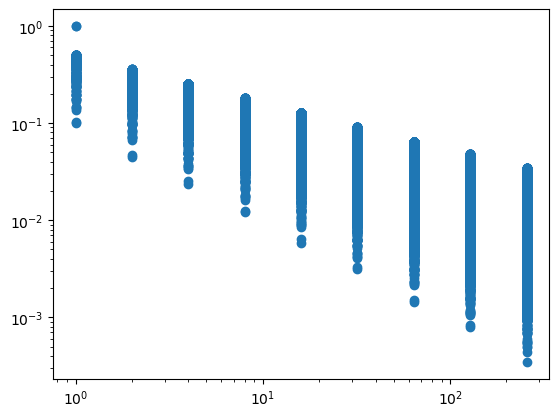

In [7]:
# show error distribution
errors_mean, errors_std = data['mu'], data['sigma']
scale_input_list = data['scale_input']
bit_length_list = data['bit_length']
plt.figure(dpi=100)
plt.plot(bit_length_list, errors_std, 'o', label='std error')
#1/sqrt(N) trend line
# N = np.array(np.unique(bit_length_list))
# plt.plot(N, 1/np.sqrt(N), label='1/sqrt(N) trend')
# using log
plt.yscale('log')
plt.xscale('log')

# MUX-based average Pooling

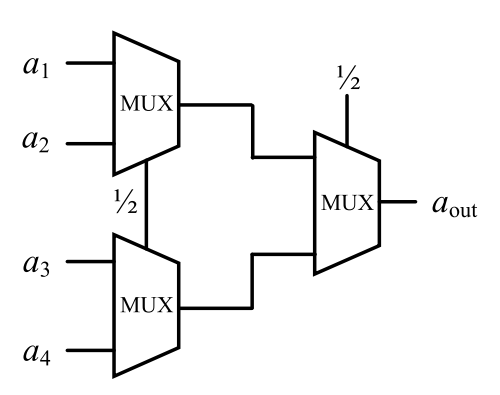

Convolution Kernel:
[[0.75  0.5  ]
 [0.25  0.875]]
Pooling MSE: 0.0057659149169921875
Convolution MSE: 0.6568355560302734


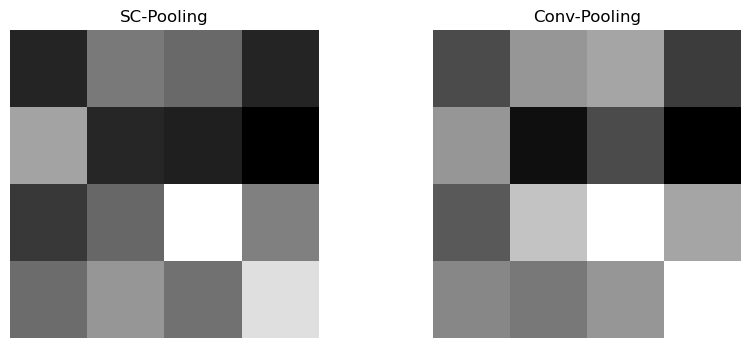

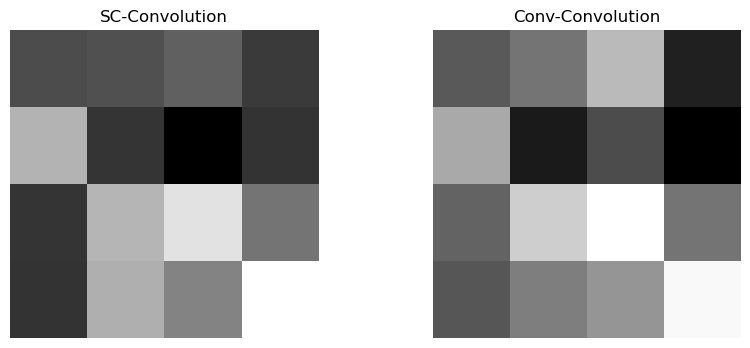

(0.0057659149169921875, 0.6568355560302734)

In [9]:
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from qihc.stochastic import sc_avg_pooling, sc_convolution

# Conventional Average Pooling without OpenCV (using NumPy)
def conventional_avg_pooling(input_matrix, pool_size=2, stride=2):
    height, width = input_matrix.shape
    out_height = (height - pool_size) // stride + 1
    out_width = (width - pool_size) // stride + 1
    pooled_matrix = np.zeros((out_height, out_width))

    for i in range(out_height):
        for j in range(out_width):
            # Define the pooling region
            h_start, h_end = i * stride, i * stride + pool_size
            w_start, w_end = j * stride, j * stride + pool_size
            pool_region = input_matrix[h_start:h_end, w_start:w_end]
            # Compute the average of the pooling region
            pooled_matrix[i, j] = np.mean(pool_region)
    
    return pooled_matrix

# Conventional Convolution without OpenCV (using NumPy)
def conventional_convolution(input_matrix, kernel, stride=1):
    in_height, in_width = input_matrix.shape
    k_height, k_width = kernel.shape
    out_height = (in_height - k_height) // stride + 1
    out_width = (in_width - k_width) // stride + 1
    output_matrix = np.zeros((out_height, out_width))

    for i in range(out_height):
        for j in range(out_width):
            conv_sum = 0.0
            # Perform convolution operation
            for m in range(k_height):
                for n in range(k_width):
                    conv_sum += input_matrix[i * stride + m, j * stride + n] * kernel[m, n]
            output_matrix[i, j] = conv_sum

    return output_matrix

# Function to compare Stochastic and Conventional Pooling and Convolution
def compare_pooling_and_convolution(sc_avg_pooling_func, sc_convolution_func, conventional_avg_pooling_func, conventional_convolution_func, input_matrix, kernel, pool_size=2, stride=2, scale_input=1.0, scale_mux=0.5, bit_length=256):
    # Perform Stochastic Pooling
    sc_pooled = sc_avg_pooling_func(input_matrix, pool_size, stride, scale_input, bit_length)
    
    # Perform Conventional Pooling
    conv_pooled = conventional_avg_pooling_func(input_matrix, pool_size, stride)

    # Perform Stochastic Convolution
    sc_conv = sc_convolution_func(input_matrix, kernel, stride, scale_input, scale_mux, bit_length)
    # normalize sc_conv to [0, 1] for better comparison

    # Perform Conventional Convolution
    conv_conv = conventional_convolution_func(input_matrix, kernel, stride)
    # normalize conv_conv to [0, 1] for better comparison

    # Calculate Mean Squared Error (MSE) between stochastic and conventional methods for pooling
    mse_pooling = mean_squared_error(sc_pooled, conv_pooled)
    
    # Calculate Mean Squared Error (MSE) between stochastic and conventional methods for convolution
    mse_convolution = mean_squared_error(sc_conv, conv_conv)
    
    # Print out results
    print(f"Pooling MSE: {mse_pooling}")
    print(f"Convolution MSE: {mse_convolution}")

    # Optionally plot results
    plt.figure(figsize=(10, 4))

    # Plot Pooling Comparison
    plt.subplot(1, 2, 1)
    plt.title("SC-Pooling")
    plt.imshow(sc_pooled, cmap='gray')
    plt.axis('off')

    
    plt.subplot(1, 2, 2)
    plt.title("Conv-Pooling")
    plt.imshow(conv_pooled, cmap='gray')
    plt.axis('off')

    # Plot Convolution Comparison
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title("SC-Convolution")
    plt.imshow(sc_conv, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Conv-Convolution")
    plt.imshow(conv_conv, cmap='gray')
    plt.axis('off')

    plt.show()

    return mse_pooling, mse_convolution

# Generate a random input feature map (e.g., 8x8 matrix)
input_matrix = np.random.rand(8, 8)
input_matrix = np.round(input_matrix * 8) / 8  # if quantification using bitstreangth 8
# Define a simple convolution kernel (e.g., 2x2 kernel)
kernel = np.random.rand(2, 2)
# quantification using bitstreangth 8
kernel = np.round(kernel * 8) / 8
print("Convolution Kernel:")
print(kernel)

# # Perform comparison
compare_pooling_and_convolution(
    sc_avg_pooling,  # Your stochastic average pooling function
    sc_convolution,  # Your stochastic convolution function
    conventional_avg_pooling,  # Conventional average pooling
    conventional_convolution,  # Conventional convolution
    input_matrix,  # Input matrix (feature map)
    kernel,  # Convolution kernel
    pool_size=2,
    stride=2,
    scale_input=1,
    scale_mux=0.5,
    bit_length=256
)